In [1]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Model

In [2]:
# Example: reverse sequence task
input_texts = ["hello", "world", "india", "neural"]
target_texts = [text[::-1] for text in input_texts]

# Character-level tokenization
chars = sorted(list(set("".join(input_texts + target_texts))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}

max_len = max(len(txt) for txt in input_texts)

def encode(texts):
    X = []
    for t in texts:
        seq = [char2idx[c] for c in t]
        seq += [0]*(max_len - len(seq))
        X.append(seq)
    return np.array(X)

X = encode(input_texts)
y = encode(target_texts)

# Expand dims for embedding compatibility
y = np.expand_dims(y, -1)

In [3]:
class Attention(Layer):
    def call(self, encoder_outputs, decoder_hidden):
        # Score calculation
        score = tf.matmul(encoder_outputs, decoder_hidden, transpose_b=True)
        attention_weights = tf.nn.softmax(score, axis=1)

        # Context vector
        context = tf.matmul(attention_weights, encoder_outputs, transpose_a=True)

        return context, attention_weights

In [5]:
embedding_dim = 16
units = 32
vocab_size = len(char2idx) + 1

# Encoder
encoder_inputs = tf.keras.Input(shape=(max_len,))
enc_emb = tf.keras.layers.Embedding(vocab_size, embedding_dim)(encoder_inputs)
encoder_outputs, state_h = tf.keras.layers.GRU(units, return_sequences=True, return_state=True)(enc_emb)

# Decoder
decoder_inputs = tf.keras.Input(shape=(max_len,))
dec_emb = tf.keras.layers.Embedding(vocab_size, embedding_dim)(decoder_inputs)
decoder_gru = tf.keras.layers.GRU(units, return_sequences=True, return_state=True)
decoder_outputs, _ = decoder_gru(dec_emb, initial_state=state_h)

# Attention
attention = Attention()
context, attn_weights = attention(encoder_outputs, decoder_outputs)

# Combine context + decoder output using Keras Concatenate layer
concat = tf.keras.layers.Concatenate(axis=-1)([context, decoder_outputs])

# Output layer
outputs = tf.keras.layers.Dense(vocab_size, activation="softmax")(concat)

model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 6, 16)     │        192 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ [(None, 6, 32),   │      4,800 │ embedding_2[0][0] │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 6, 16)     │        192 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ [(None, 6, 32),   │      4,800 │ embedding_3[0][0… │
│                     │ (None, 32)]       │            │ gru_2[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ [(None, 6, 32),   │          0 │ gru_2[0][0],      │
│ (Attention)         │ (None, 6, 6)]     │            │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 64)     │          0 │ attention_1[0][0… │
│ (Concatenate)       │                   │            │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 12)     │        780 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,764 (42.05 KB)

 Trainable params: 10,764 (42.05 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

model.fit([X, X], y, epochs=20, batch_size=2)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 2.4845
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.4789
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.4740
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.4692 
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.4646
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.4594
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.4540
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.4492
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4439
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.4376
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.4318
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4246
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.4174
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4102
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.4007
Epoch 16/20
2/2 ━━━━━━━━━━━━━━━━━

In [7]:
# Create separate model to output attention weights
attention_model = Model(
    inputs=model.input,
    outputs=attn_weights
)

sample_input = X[0:1]
attn = attention_model.predict([sample_input, sample_input])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step


/tmp/ipykernel_3483/1379271840.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_text))
/tmp/ipykernel_3483/1379271840.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + list(output_text))


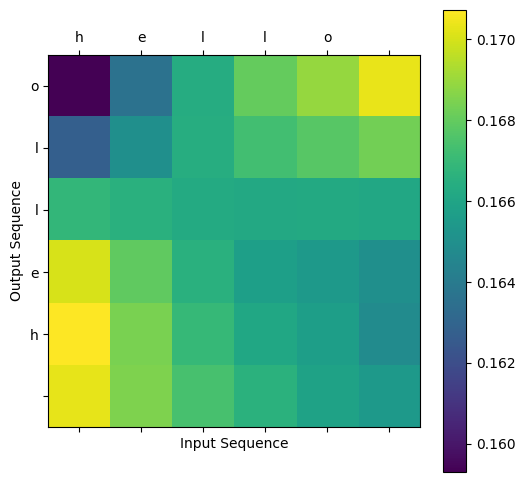

In [8]:
def plot_attention(attention, input_text, output_text):
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(attention, cmap='viridis')

    ax.set_xticklabels([''] + list(input_text))
    ax.set_yticklabels([''] + list(output_text))

    plt.xlabel("Input Sequence")
    plt.ylabel("Output Sequence")
    plt.colorbar(cax)
    plt.show()

input_seq = input_texts[0]
output_seq = target_texts[0]

# Remove batch dimension
attention_matrix = attn[0]

plot_attention(attention_matrix, input_seq, output_seq)